In [1]:
import pandas as pd

# Load the source dataset
csv_path = "../data/source.csv"
source_df = pd.read_csv(csv_path)

# Display the data
source_df

,claim_number,age_of_driver,gender,marital_status,safty_rating,annual_income,high_education_ind,address_change_ind,living_status,zip_code,...,liab_prct,channel,policy_report_filed_ind,claim_est_payout,age_of_vehicle,vehicle_category,vehicle_price,vehicle_color,vehicle_weight,fraud
0,0,50,F,1.0,66,39117,1,0,Own,50051,...,18,Broker,0,5464.903723,3.0,Large,16786.288450,blue,34183.436390,0
1,1,47,M,1.0,78,38498,1,0,Own,50012,...,81,Broker,0,5448.155974,4.0,Large,20793.298810,black,14528.379730,0
2,2,28,M,0.0,76,33343,0,1,Rent,20158,...,94,Broker,1,1858.971699,4.0,Compact,6729.476490,blue,7182.832636,0
3,3,36,M,1.0,56,35832,1,0,Own,50054,...,95,Phone,0,4040.932844,5.0,Compact,24914.267850,gray,47891.788790,0
4,4,60,F,1.0,79,40948,1,1,Rent,80010,...,53,Phone,1,4876.606138,6.0,Medium,17392.419970,black,7546.494014,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18995,18995,53,M,0.0,81,39711,1,1,Rent,85070,...,35,Broker,1,9528.853233,7.0,Compact,8285.507871,black,19578.388760,0
18996,18996,39,F,1.0,76,36644,0,1,Rent,80020,...,2,Broker,1,3895.307825,4.0,Medium,11536.180460,silver,17599.182810,0
18997,18997,46,M,1.0,91,38291,0,0,Rent,15019,...,89,Broker,1,2851.046390,6.0,Compact,13601.011440,gray,20711.012560,0
18998,18998,40,M,0.0,87,36895,1,1,Own,20142,...,98,Broker,1,3593.339941,5.0,Compact,38314.191020,red,33472.728910,0


In [2]:
# Check missing values per column
missing_counts = source_df.isna().sum().sort_values(ascending=False)
missing_counts

witness_present_ind        143
claim_est_payout            23
age_of_vehicle               7
marital_status               4
claim_number                 0
annual_income                0
age_of_driver                0
gender                       0
safty_rating                 0
living_status                0
address_change_ind           0
high_education_ind           0
zip_code                     0
accident_site                0
past_num_of_claims           0
claim_day_of_week            0
claim_date                   0
channel                      0
liab_prct                    0
policy_report_filed_ind      0
vehicle_category             0
vehicle_price                0
vehicle_color                0
vehicle_weight               0
fraud                        0
dtype: int64

In [3]:
# Drop rows with any missing values
clean_df = source_df.dropna()

# Quick check
clean_df.isna().sum().sum()

np.int64(0)

In [4]:
# Plot distribution for the fraud feature (auto-detect fraud column)
fraud_cols = [col for col in source_df.columns if "fraud" in col.lower()]
fraud_cols

['fraud']

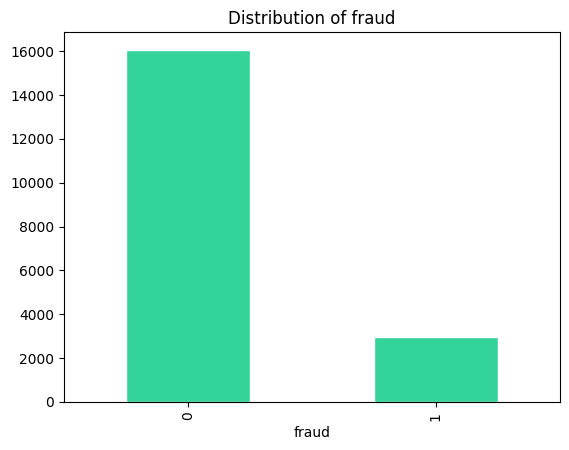

In [5]:
# Plot distribution of the first fraud-related column, if found
if fraud_cols:
    fraud_col = fraud_cols[0]
    source_df[fraud_col].value_counts().sort_index().plot(
        kind="bar",
        color="#34d399",
        edgecolor="white",
        title=f"Distribution of {fraud_col}",
    )
else:
    print("No column with 'fraud' in its name was found.")

In [ ]:
import matplotlib.pyplot as plt

# Plot distributions for rows where fraud feature == 1
if fraud_cols:
    fraud_col = fraud_cols[0]
    fraud_one_df = source_df[source_df[fraud_col] == 1]

    numeric_cols = fraud_one_df.select_dtypes(include="number").columns
    categorical_cols = [col for col in fraud_one_df.columns if col not in numeric_cols]

    # Numeric features
    if len(numeric_cols) > 0:
        n_cols = 3
        n_rows = (len(numeric_cols) + n_cols - 1) // n_cols
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
        axes = axes.flatten() if len(numeric_cols) else []

        for idx, col in enumerate(numeric_cols):
            ax = axes[idx]
            ax.hist(
                fraud_one_df[col].dropna(), bins=30, color="#f87171", edgecolor="white"
            )
            ax.set_title(f"{col} (fraud=1)")
            ax.set_xlabel(col)
            ax.set_ylabel("Count")

        for ax in axes[len(numeric_cols) :]:
            ax.axis("off")

        plt.tight_layout()
        plt.show()

    # Categorical features
    if len(categorical_cols) > 0:
        n_cols = 3
        n_rows = (len(categorical_cols) + n_cols - 1) // n_cols
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
        axes = axes.flatten() if len(categorical_cols) else []

        for idx, col in enumerate(categorical_cols):
            ax = axes[idx]
            counts = fraud_one_df[col].value_counts(dropna=False).head(20)
            ax.bar(
                counts.index.astype(str),
                counts.values,
                color="#f59e0b",
                edgecolor="white",
            )
            ax.set_title(f"{col} (fraud=1)")
            ax.set_ylabel("Count")
            ax.tick_params(axis="x", rotation=45)

        for ax in axes[len(categorical_cols) :]:
            ax.axis("off")

        plt.tight_layout()
        plt.show()
else:
    print("No column with 'fraud' in its name was found.")

In [ ]:
# Count rows where fraud feature equals 1 and 0
if fraud_cols:
    fraud_col = fraud_cols[0]
    fraud_counts = source_df[fraud_col].value_counts(dropna=False)
    fraud_counts.loc[[0, 1]] if {0, 1}.issubset(fraud_counts.index) else fraud_counts
    display(fraud_counts)
else:
    print("No column with 'fraud' in its name was found.")

fraud
0    16062
1     2938
Name: count, dtype: int64

In [8]:
# Create a new balanced dataframe by upsampling fraud=1 rows
import numpy as np

if fraud_cols:
    fraud_col = fraud_cols[0]
    base_df = clean_df.copy()

    fraud_one = base_df[base_df[fraud_col] == 1]
    fraud_zero = base_df[base_df[fraud_col] == 0]

    n_needed = len(fraud_zero) - len(fraud_one)

    if n_needed > 0:
        numeric_cols = fraud_one.select_dtypes(include="number").columns.tolist()
        categorical_cols = [col for col in fraud_one.columns if col not in numeric_cols]

        # Precompute categorical distributions from fraud=1 subset
        cat_distributions = {
            col: fraud_one[col].value_counts(normalize=True, dropna=False)
            for col in categorical_cols
        }

        synthetic_rows = []
        for _ in range(n_needed):
            row = {}
            # Numeric: bootstrap from fraud=1 subset
            for col in numeric_cols:
                row[col] = fraud_one[col].sample(1, replace=True).iloc[0]
            # Categorical: sample using fraud=1 frequency distribution
            for col in categorical_cols:
                probs = cat_distributions[col]
                row[col] = np.random.choice(probs.index, p=probs.values)
            synthetic_rows.append(row)

        synthetic_df = pd.DataFrame(synthetic_rows)
        balanced_df = pd.concat([base_df, synthetic_df], ignore_index=True)
    else:
        balanced_df = base_df.copy()

    # Show counts after balancing
    balanced_df[fraud_col].value_counts()
else:
    print("No column with 'fraud' in its name was found.")

In [ ]:
# Plot distributions for fraud=1 rows in base and balanced dataframes
import matplotlib.pyplot as plt

if fraud_cols:
    fraud_col = fraud_cols[0]

    def plot_distributions(df, title_suffix):
        fraud_one_df = df[df[fraud_col] == 1]
        numeric_cols = fraud_one_df.select_dtypes(include="number").columns
        categorical_cols = [
            col for col in fraud_one_df.columns if col not in numeric_cols
        ]

        if len(numeric_cols) > 0:
            n_cols = 3
            n_rows = (len(numeric_cols) + n_cols - 1) // n_cols
            fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
            axes = axes.flatten() if len(numeric_cols) else []

            for idx, col in enumerate(numeric_cols):
                ax = axes[idx]
                ax.hist(
                    fraud_one_df[col].dropna(),
                    bins=30,
                    color="#60a5fa",
                    edgecolor="white",
                )
                ax.set_title(f"{col} ({title_suffix})")
                ax.set_xlabel(col)
                ax.set_ylabel("Count")

            for ax in axes[len(numeric_cols) :]:
                ax.axis("off")

            plt.tight_layout()
            plt.show()

        if len(categorical_cols) > 0:
            n_cols = 3
            n_rows = (len(categorical_cols) + n_cols - 1) // n_cols
            fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
            axes = axes.flatten() if len(categorical_cols) else []

            for idx, col in enumerate(categorical_cols):
                ax = axes[idx]
                counts = fraud_one_df[col].value_counts(dropna=False).head(20)
                ax.bar(
                    counts.index.astype(str),
                    counts.values,
                    color="#34d399",
                    edgecolor="white",
                )
                ax.set_title(f"{col} ({title_suffix})")
                ax.set_ylabel("Count")
                ax.tick_params(axis="x", rotation=45)

            for ax in axes[len(categorical_cols) :]:
                ax.axis("off")

            plt.tight_layout()
            plt.show()

    plot_distributions(clean_df, "clean_df fraud=1")
    plot_distributions(balanced_df, "balanced_df fraud=1")
else:
    print("No column with 'fraud' in its name was found.")

In [10]:
# Counts for fraud=1 and fraud=0 in the balanced dataframe
if fraud_cols:
    fraud_col = fraud_cols[0]
    display(balanced_df[fraud_col].value_counts(dropna=False))
else:
    print("No column with 'fraud' in its name was found.")

fraud
0    15907
1    15907
Name: count, dtype: int64

In [ ]:
# Save balanced dataframe to a parquet file
output_path = "../data/full_balanced.parquet"
balanced_df.to_parquet(output_path, index=False)
output_path

'../data/full_balanced.parquet'

In [ ]:
# Load balanced parquet and split into train/test (80/20)
import pandas as pd
from sklearn.model_selection import train_test_split

balanced_path = "../data/full_balanced.parquet"
full_balanced_df = pd.read_parquet(balanced_path)

train_df, test_df = train_test_split(
    full_balanced_df,
    test_size=0.2,
    random_state=42,
    shuffle=True,
)

(train_df.shape, test_df.shape)

((25451, 25), (6363, 25))

In [ ]:
# Stratified split to keep fraud class balance in train/test
fraud_cols = ["fraud"]
if fraud_cols:
    fraud_col = fraud_cols[0]
    train_df, test_df = train_test_split(
        full_balanced_df,
        test_size=0.2,
        random_state=42,
        shuffle=True,
        stratify=full_balanced_df[fraud_col],
    )

    # Verify class counts in train/test
    train_counts = train_df[fraud_col].value_counts()
    test_counts = test_df[fraud_col].value_counts()
    display(train_counts, test_counts)
else:
    print("No column with 'fraud' in its name was found.")

fraud
1    12726
0    12725
Name: count, dtype: int64

fraud
0    3182
1    3181
Name: count, dtype: int64

In [ ]:
# Keep only features used by the frontend (top 10 by SHAP importance)
FEATURE_COLS = [
    "annual_income",
    "age_of_driver",
    "claim_day_of_week",
    "high_education_ind",
    "past_num_of_claims",
    "safty_rating",
    "witness_present_ind",
    "gender",
    "claim_est_payout",
    "living_status",
]
train_df = train_df[FEATURE_COLS + ["fraud"]]
test_df = test_df[FEATURE_COLS + ["fraud"]]

# Save train/test dataframes to parquet files
train_path = "../data/train.parquet"
test_path = "../data/test.parquet"

train_df.to_parquet(train_path, index=False)
test_df.to_parquet(test_path, index=False)

('../data/train.parquet', '../data/test.parquet')